# Qiskit route construction example

This notebook builds the route register, reversible validity oracle, validity-controlled cost-phase oracle, and uncomputation, then reproduces the tours/\(\phi\)/validity table with Aer statevector simulation.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import transpile
from qiskit.visualization import circuit_drawer
from qiskit_aer import Aer

import src.classical_funcs as cf
from src.qiskit_route_construction import (
    build_qiskit_tsp_construction_circuit,
    build_route_phase_table,
)

In [2]:
n = 5
seed = 42
csv_out = 'qiskit_tsp_table.csv'
table_plot_out = 'qiskit_tsp_table.png'
validity_plot_out = 'qiskit_tsp_validity_phi.png'
circuit_plot_out = 'qiskit_tsp_circuit.png'

In [3]:
def build_normalized_cost_matrix(n: int, seed: int) -> np.ndarray:
    np.random.seed(seed)
    raw = cf.generate_cost_matrix(n)

    mask = ~np.eye(n, dtype=bool)
    cmin = float(np.min(raw[mask]))
    cmax = float(np.max(raw[mask]))
    delta = cmax - cmin

    if np.isclose(delta, 0.0):
        raise ValueError("Cannot normalize a constant cost matrix.")

    scaled = np.zeros_like(raw)
    scaled[mask] = (raw[mask] - cmin) / (n * delta)
    return scaled    

def route_to_bitstring(route, bits_per_step: int) -> str:
    return ''.join(format(int(city), f'0{bits_per_step}b') for city in route)

In [4]:
cost_matrix = build_normalized_cost_matrix(n=n, seed=seed)
circuit, layout = build_qiskit_tsp_construction_circuit(cost_matrix=cost_matrix, start_node=n - 1)

backend = Aer.get_backend('statevector_simulator')
compiled = transpile(circuit, backend=backend)
result = backend.run(compiled).result()
statevector = np.asarray(result.get_statevector(compiled))

In [5]:
df = build_route_phase_table(statevector=statevector, layout=layout, cost_matrix=cost_matrix)
df['bitstring'] = df['tour'].apply(lambda tour: route_to_bitstring(tour, layout.bits_per_step))
df['tour_key'] = df['tour'].apply(tuple)
df = df.sort_values(by=['validity', 'expected_phi', 'tour_key'], ascending=[False, True, True]).reset_index(drop=True)
df = df.drop(columns=['tour_key'])
df.to_csv(csv_out, index=False)
df = df.round({"phi": 2})
df = df.round({"expected_phi": 2})
# df.head(26)
tab=df.to_latex(columns=["tour", "phi", "validity"], index=False)
print(tab)

\begin{tabular}{lrr}
\toprule
tour & phi & validity \\
\midrule
[2, 3, 1, 0] & 0.210000 & 1 \\
[1, 3, 2, 0] & 0.280000 & 1 \\
[1, 0, 2, 3] & 0.300000 & 1 \\
[1, 2, 3, 0] & 0.310000 & 1 \\
[1, 0, 3, 2] & 0.320000 & 1 \\
[3, 1, 2, 0] & 0.340000 & 1 \\
[3, 1, 0, 2] & 0.340000 & 1 \\
[1, 3, 0, 2] & 0.370000 & 1 \\
[1, 2, 0, 3] & 0.380000 & 1 \\
[2, 0, 3, 1] & 0.380000 & 1 \\
[2, 0, 1, 3] & 0.430000 & 1 \\
[3, 2, 1, 0] & 0.440000 & 1 \\
[2, 1, 3, 0] & 0.440000 & 1 \\
[2, 1, 0, 3] & 0.460000 & 1 \\
[2, 3, 0, 1] & 0.470000 & 1 \\
[3, 0, 1, 2] & 0.520000 & 1 \\
[0, 3, 1, 2] & 0.520000 & 1 \\
[0, 2, 3, 1] & 0.520000 & 1 \\
[3, 2, 0, 1] & 0.520000 & 1 \\
[0, 1, 3, 2] & 0.580000 & 1 \\
[0, 1, 2, 3] & 0.600000 & 1 \\
[3, 0, 2, 1] & 0.600000 & 1 \\
[0, 2, 1, 3] & 0.650000 & 1 \\
[0, 3, 2, 1] & 0.700000 & 1 \\
[0, 0, 0, 0] & 0.000000 & 0 \\
[0, 0, 0, 1] & 0.000000 & 0 \\
[0, 0, 0, 2] & 0.000000 & 0 \\
[0, 0, 0, 3] & 0.000000 & 0 \\
[0, 0, 1, 0] & 0.000000 & 0 \\
[0, 0, 1, 1] & 0.000000 & 0 \\
[0, 0,

In [6]:
# fig_height = max(8, 0.18 * len(df))
# fig, ax = plt.subplots(figsize=(16, fig_height))
# ax.axis('off')
# table = ax.table(cellText=df.values, colLabels=df.columns, loc='center', cellLoc='center')
# table.auto_set_font_size(False)
# table.set_fontsize(6)
# table.scale(1.0, 1.1)
# fig.tight_layout()
# fig.savefig(table_plot_out, dpi=200, bbox_inches='tight')
# plt.show()
# plt.close(fig)

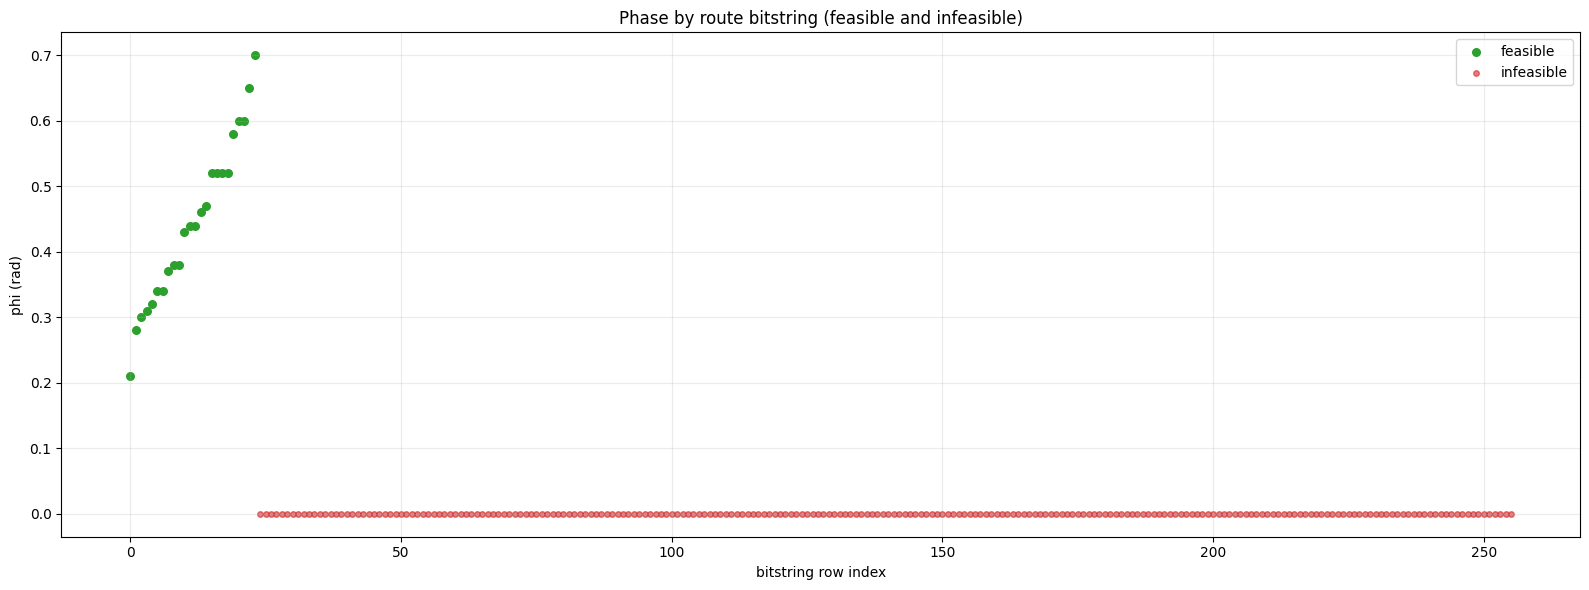

In [7]:
df_plot = df.copy()
df_plot['row'] = np.arange(len(df_plot))

valid = df_plot[df_plot['validity'] == 1]
invalid = df_plot[df_plot['validity'] == 0]

fig, ax = plt.subplots(figsize=(16, 6))
ax.scatter(valid['row'], valid['phi'], s=30, label='feasible', color='tab:green')
ax.scatter(invalid['row'], invalid['phi'], s=16, label='infeasible', color='tab:red', alpha=0.6)
ax.set_xlabel('bitstring row index')
ax.set_ylabel('phi (rad)')
ax.set_title('Phase by route bitstring (feasible and infeasible)')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(validity_plot_out, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

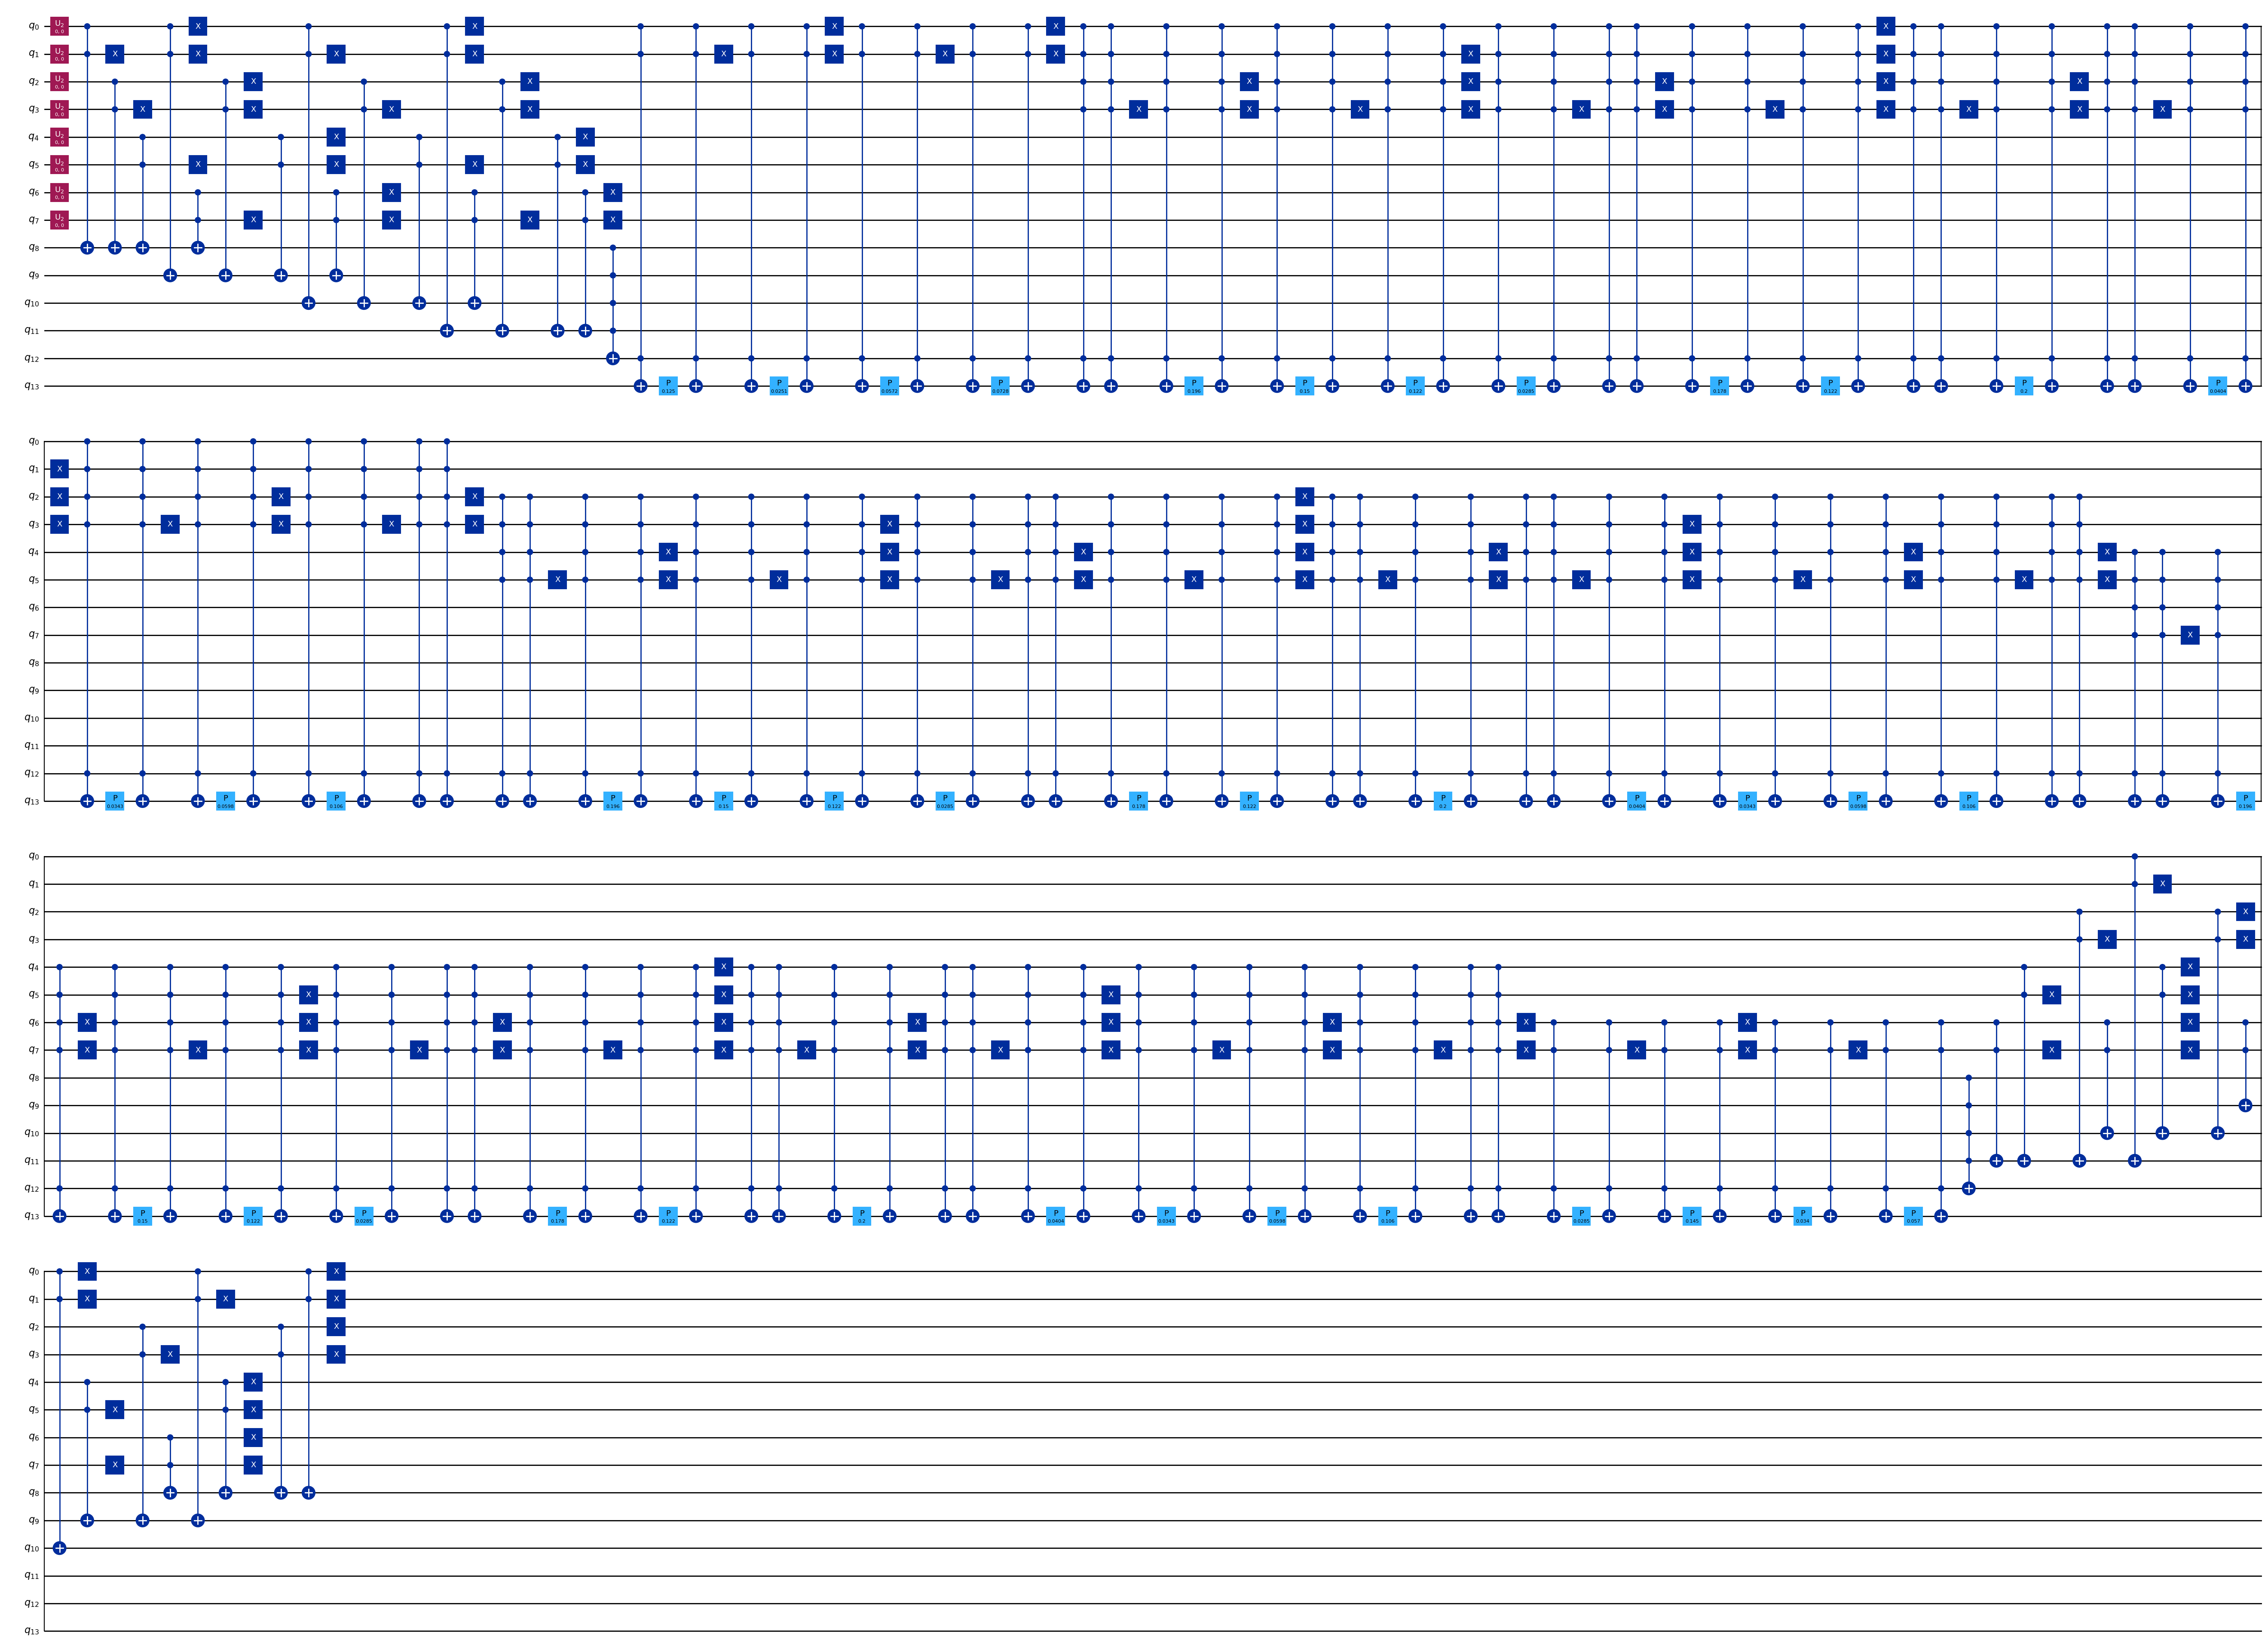

In [8]:
fig = circuit_drawer(compiled, output='mpl', fold=80, idle_wires=False)
fig.savefig(circuit_plot_out, dpi=200, bbox_inches='tight')
display(fig)
# plt.show()
# plt.close(fig)

In [9]:
print(f'Saved table CSV: {csv_out}')
print(f'Saved full table plot: {table_plot_out}')
print(f'Saved feasible/infeasible phase plot: {validity_plot_out}')
print(f'Saved circuit plot: {circuit_plot_out}')

Saved table CSV: qiskit_tsp_table.csv
Saved full table plot: qiskit_tsp_table.png
Saved feasible/infeasible phase plot: qiskit_tsp_validity_phi.png
Saved circuit plot: qiskit_tsp_circuit.png
